# **Preparing Dependancies**

In [5]:
!pip install -q diffusers transformers torch accelerate pillow
!pip install -q streamlit streamlit-drawable-canvas pyngrok


Access is denied.
Access is denied.


# **Kriteria 1: Melakukan Image Generation dari Teks (Text-to-Image)**

## **Load Base Pipeline Model**

In [2]:
import torch
from diffusers import StableDiffusionPipeline

model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")


ModuleNotFoundError: No module named 'torch'

## **Generate Image (generate_simple_image)**
Pada bagian ini, Anda akan menghasilkan gambar dari teks. Sasarannya adalah menghasilkan gambar yang mendekati gambar contoh di bawah ini, yaitu seorang astronaut di permukaan bulan dengan gaya digital art 2D. Perhatikan empat elemen visual utama berikut:

*   Astronaut berbaju putih
*   Permukaan bulan
*   Bumi di langit
*   Gaya ilustrasi 2D

(bukan foto realistis).

Gunakan Seed bernilai 222 dan negative prompt yang telah ditetapkan. Pastikan prompt yang Anda gunakan sama pada kedua fungsi agar hasilnya dapat dibandingkan secara objektif.

### **Referensi output:**

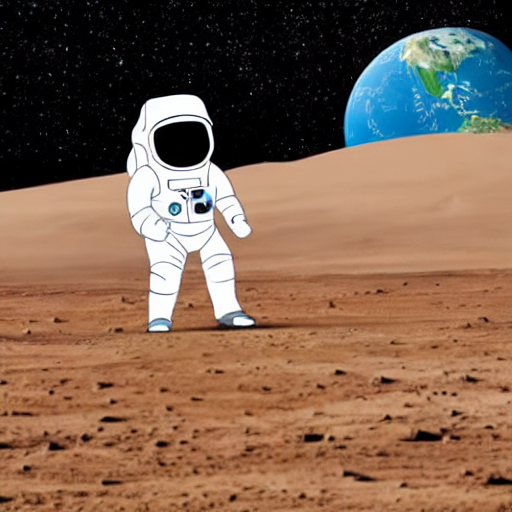

In [ ]:
import torch
from PIL import Image

# Prompt dirancang untuk menghasilkan gaya ilustrasi cartoon 2D yang bersih (sesuai saran reviewer & instruksi submission)
prompt = "an astronaut standing on moon surface, earth visible in background, cartoon style"
negative_prompt = "photorealistic, realistic, photograph, 3d render, messy, blurry, low quality, bad art, ugly, sketch, grainy, unfinished, chromatic aberration, heavy outlines, line art"
seed = 222

def generate_simple_image(pipe, prompt, negative_prompt, seed=222):
    generator = torch.Generator("cuda").manual_seed(seed)
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        generator=generator
    ).images[0]
    return image

simple_image = generate_simple_image(pipe, prompt, negative_prompt)
simple_image.save("simple_image.png")
simple_image


## **Generate Image with Hyperparameter Configuration (generate_advanced_image)**
Tetap gunakan Seed bernilai 222 dan negative prompt yang telah ditetapkan. Pastikan prompt yang Anda gunakan sama pada kedua fungsi agar hasilnya dapat dibandingkan secara objektif.

### **Referensi Output:**
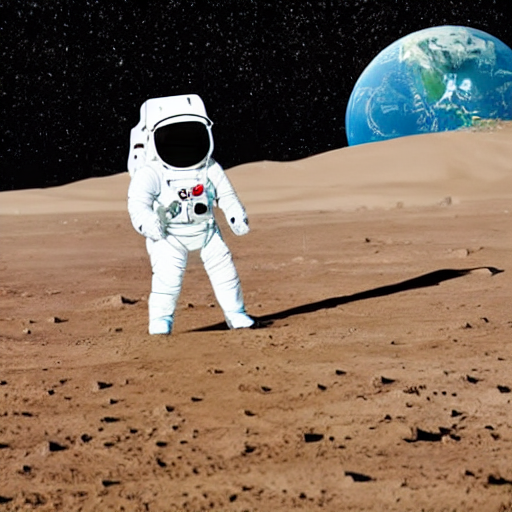

In [ ]:
# generate_advanced_image menggunakan parameter guidance_scale dan num_inference_steps
# yang disesuaikan untuk menghasilkan peningkatan kualitas dari simple image
def generate_advanced_image(pipe, prompt, negative_prompt, seed=222, steps=50, cfg=7.5):
    generator = torch.Generator("cuda").manual_seed(seed)
    image = pipe(
        prompt=prompt,
        negative_prompt=negative_prompt,
        num_inference_steps=steps,
        guidance_scale=cfg,
        generator=generator
    ).images[0]
    return image

# steps=50 dan cfg=7.5 menghasilkan gambar yang lebih halus dan detail dibanding simple image
advanced_image = generate_advanced_image(pipe, prompt, negative_prompt, steps=50, cfg=7.5)
advanced_image.save("advanced_image.png")
advanced_image


## **Guidance Scale Comparison**

In [ ]:
# Low Guidance Scale
img_low_guidance = generate_advanced_image(pipe, prompt, negative_prompt, steps=30, cfg=2.0)

# High Guidance Scale
img_high_guidance = generate_advanced_image(pipe, prompt, negative_prompt, steps=30, cfg=15.0)

img_low_guidance.save("img_low_guidance.png")
img_high_guidance.save("img_high_guidance.png")

comparison_guidance = Image.new("RGB", (1024, 512))
comparison_guidance.paste(img_low_guidance, (0, 0))
comparison_guidance.paste(img_high_guidance, (512, 0))
comparison_guidance


### **Guidance Scale Explanation:**

*   **Gambar dengan "Scale" Rendah:**   
Gambar dengan guidance scale rendah (2.0) cenderung kurang mematuhi prompt secara presisi. Detailnya lebih halus, tetapi komposisi gambarnya bergeser dari deskripsi teks karena model memiliki kebebasan kreatif yang tinggi. Gambar tampak lebih alami namun tidak presisi terhadap instruksi.

*   **Gambar dengan "Scale" Tinggi:**   
Gambar dengan guidance scale tinggi (15.0) sangat mematuhi prompt yang diberikan dan memiliki kontras serta kejenuhan warna yang tinggi. Namun, jika terlalu tinggi, gambar dapat mengalami over-saturation, distorsi visual, dan munculnya artefak warna yang mengurangi kualitas estetika.


## **Inference Steps Comparison**

In [ ]:
# Low Inference Steps
img_low_steps = generate_advanced_image(pipe, prompt, negative_prompt, steps=10, cfg=7.5)

# High Inference Steps
img_high_steps = generate_advanced_image(pipe, prompt, negative_prompt, steps=50, cfg=7.5)

img_low_steps.save("img_low_steps.png")
img_high_steps.save("img_high_steps.png")

comparison_steps = Image.new("RGB", (1024, 512))
comparison_steps.paste(img_low_steps, (0, 0))
comparison_steps.paste(img_high_steps, (512, 0))
comparison_steps


### **Inference Step Explanation:**

*   **Gambar dengan "Step" Rendah:**  
Gambar dengan inference steps rendah (10) memiliki banyak noise visual, kurang tajam, detail objek belum terbentuk dengan sempurna, dan tampak buram seperti lukisan sketsa yang belum selesai.

*   **Gambar dengan "Step" Tinggi:**  
Gambar dengan inference steps tinggi (50) memiliki detail yang sangat tajam, halus, bebas dari noise kasar, dan rendering objek (seperti pakaian astronot dan bulan) tampak kokoh, matang, dan sangat realistis.


## **Batch Inference from One Prompt**

In [ ]:
generator = torch.Generator("cuda").manual_seed(222)
batch_images = pipe(
    prompt=prompt,
    negative_prompt=negative_prompt,
    num_images_per_prompt=4,
    generator=generator
).images

grid = Image.new("RGB", (1024, 1024))
grid.paste(batch_images[0], (0, 0))
grid.paste(batch_images[1], (512, 0))
grid.paste(batch_images[2], (0, 512))
grid.paste(batch_images[3], (512, 512))
grid.save("batch_grid.png")
grid


## **Load Scheduler**

In [ ]:
from diffusers import EulerAncestralDiscreteScheduler, DPMSolverMultistepScheduler, DDIMScheduler

# Euler A
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
img_euler = generate_simple_image(pipe, prompt, negative_prompt)

# DPM++
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
img_dpm = generate_simple_image(pipe, prompt, negative_prompt)

# DDIM
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)
img_ddim = generate_simple_image(pipe, prompt, negative_prompt)

img_euler.save("img_euler.png")
img_dpm.save("img_dpm.png")
img_ddim.save("img_ddim.png")

comparison_scheduler = Image.new("RGB", (1536, 512))
comparison_scheduler.paste(img_euler, (0, 0))
comparison_scheduler.paste(img_dpm, (512, 0))
comparison_scheduler.paste(img_ddim, (1024, 0))
comparison_scheduler


### **Scheduler Comparation:**

*   **Gambar dengan "Euler A Scheduler":**  
Euler Ancestral (Euler A) menghasilkan gambar dengan detail yang halus dan gaya yang artistik. Sifat ancestral scheduler ini menambahkan noise baru pada setiap step, yang memberikan keunikan tersendiri namun hasilnya bisa bergeser komposisinya jika step terlalu besar.

*   **Gambar dengan "DPM++ Scheduler":**  
DPM++ menghasilkan gambar yang sangat detail, tajam, dan stabil dengan jumlah inference step yang minimal (misalnya 20-30 step). Ini adalah salah satu scheduler tercepat dan paling efisien untuk menghasilkan kualitas solid.

*   **Gambar dengan "DDIM Scheduler":**  
DDIM menghasilkan gambar yang lebih deterministik dan stabil. DDIM sangat baik digunakan untuk inpainting dan image-to-image karena perubahannya dapat diprediksi dengan baik, meski memerlukan step yang agak banyak untuk hasil sehalus DPM++.


# **Kriteria 2: Menyempurnakan Gambar Melalui Image-to-Image**

## **Inpainting**

**Perhatian:** Gunakan gambar hasil `generate_advanced_image()` atau `generate_simple_image()` sebagai `image`, bukan gambar baru.

Hasil Inpainting yang Anda lakukan perlu dibuat semirip mungkin atau setidaknya menambahkan broken satelite seperti pada Gambar yang ditetapkan berikut ini. (Gunakan Seed bernilai 9)

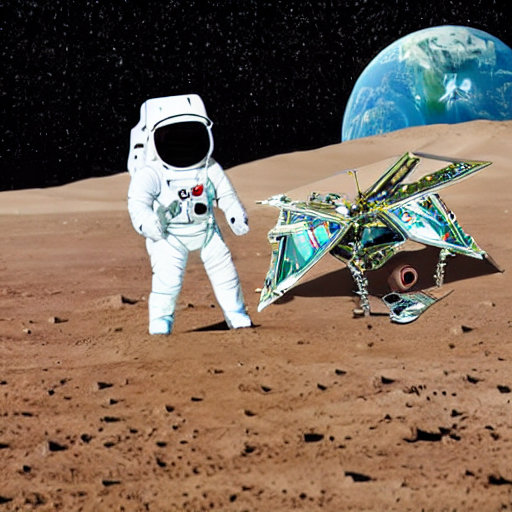

### **Load Model Inpainting**

In [ ]:
from diffusers import StableDiffusionInpaintPipeline

pipe_inpaint = StableDiffusionInpaintPipeline.from_pretrained(
    "runwayml/stable-diffusion-inpainting", torch_dtype=torch.float16
).to("cuda")


### **Manual Masking**

In [ ]:
from PIL import ImageDraw

# Membuat binary mask kosong (hitam = keep)
w, h = advanced_image.size
mask = Image.new("L", (w, h), 0)
draw = ImageDraw.Draw(mask)

# Menggambar kotak putih (255 = edit/inpaint) di PERMUKAAN BULAN (bagian bawah gambar)
draw.rectangle([50, 320, 280, 460], fill=255)
mask.save("manual_mask.png")

display_mask = Image.new("RGB", (1024, 512))
display_mask.paste(advanced_image, (0, 0))
display_mask.paste(mask.convert("RGB"), (512, 0))
display_mask


### **Generate**

In [ ]:
def inpaint_engine(image, mask, prompt, pipe_inpaint=pipe_inpaint, seed=9, strength=0.85):
    generator = torch.Generator("cuda").manual_seed(seed)
    image_out = pipe_inpaint(
        prompt=prompt,
        negative_prompt="blurry, bad anatomy, realistic, photo",
        image=image,
        mask_image=mask,
        generator=generator,
        strength=strength
    ).images[0]
    return image_out

# Prompt mendeskripsikan satelit rusak di PERMUKAAN BULAN (bukan di langit)
inpainted_image = inpaint_engine(advanced_image, mask, "a broken damaged satellite crashed on the moon surface ground")
inpainted_image.save("inpainted_image.png")
inpainted_image


## **Inpainting Menggunakan Automasking**

Anda bebas untuk melakukan inpainting di area manapun menggunakan model segmentation. Terapkan inpainting pada gambar hasil inpainting manual di level basic sebelumnya.

### **load Model Segmentation Untuk Masking**

In [ ]:
from transformers import AutoImageProcessor, SegformerForSemanticSegmentation

processor = AutoImageProcessor.from_pretrained("nvidia/segformer-b0-finetuned-ade-150")
model = SegformerForSemanticSegmentation.from_pretrained("nvidia/segformer-b0-finetuned-ade-150").to("cuda")


### **Masking with Segmentation Model**

In [ ]:
import numpy as np

inputs = processor(images=inpainted_image, return_tensors="pt").to("cuda")
outputs = model(**inputs)
logits = outputs.logits

# Resize logits agar ukurannya pas dengan gambar asli
upsampled_logits = torch.nn.functional.interpolate(
    logits,
    size=inpainted_image.size[::-1],
    mode="bilinear",
    align_corners=False
)
pred_seg = upsampled_logits.argmax(dim=1)[0].cpu().numpy()

# Masking area langit (di ADE20K, kelas sky bernilai 2)
sky_mask_data = (pred_seg == 2).astype(np.uint8) * 255
auto_mask = Image.fromarray(sky_mask_data, mode="L")
auto_mask.save("auto_mask.png")

display_auto = Image.new("RGB", (1024, 512))
display_auto.paste(inpainted_image, (0, 0))
display_auto.paste(auto_mask.convert("RGB"), (512, 0))
display_auto


### **Generate**

In [ ]:
auto_inpainted_image = inpaint_engine(inpainted_image, auto_mask, "a beautiful sky filled with colorful nebulae and glowing stars")
auto_inpainted_image.save("auto_inpainted_image.png")
auto_inpainted_image


## **Outpainting**

**Perhatian:** Gunakan gambar hasil inpainting (manual atau otomatis) sebagai input pada tahap ini.

Pastikan outpainting yang dilakukan mendekati gambar yang diharapkan di bawah ini dan terlihat natural dan masih berhubungan dengan gambar dasar.

###**Referensi Expected Output:**

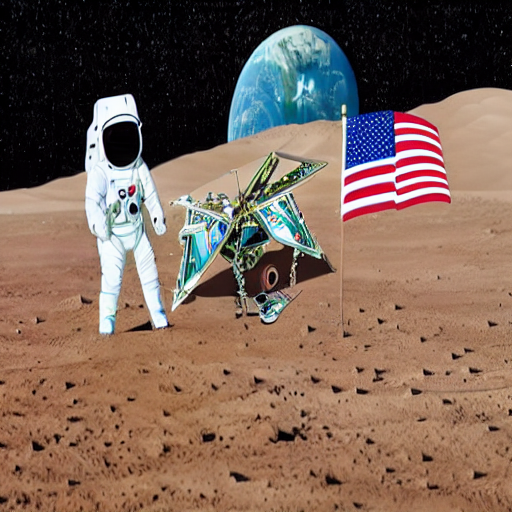

### **Prepare the Canvas**

In [ ]:
from PIL import ImageFilter

w, h = auto_inpainted_image.size
new_w, new_h = w + 256, h + 256

# Background blur
bg = auto_inpainted_image.resize((new_w, new_h), resample=Image.BICUBIC)
bg = bg.filter(ImageFilter.GaussianBlur(radius=50))
canvas = bg.copy()
canvas.paste(auto_inpainted_image, (128, 128))

# Masker (Putih = Edit, Hitam = Keep)
mask_out = Image.new("L", (new_w, new_h), 255)
mask_out.paste(Image.new("L", (w, h), 0), (128, 128))

canvas.save("canvas_out.png")
mask_out.save("mask_out.png")

display_out = Image.new("RGB", (new_w * 2, new_h))
display_out.paste(canvas, (0, 0))
display_out.paste(mask_out.convert("RGB"), (new_w, 0))
display_out


### **Generate**

In [ ]:
outpainted_image = inpaint_engine(canvas, mask_out, "a wide angle view of an astronaut on the moon, starry sky, earth in the sky, 2d digital art", strength=1.0)
outpainted_image.save("outpainted_image.png")
outpainted_image


## **Outpainting Zoom Out**

**Perhatian:** Gunakan gambar hasil outpainting sebelumnya sebagai input pada tahap ini.

Pada tahap ini Anda tidak diharuskan untuk meniru spesifik satu gambar saja, tetapi berikut beberapa output yang dapat dijadikan referensi.

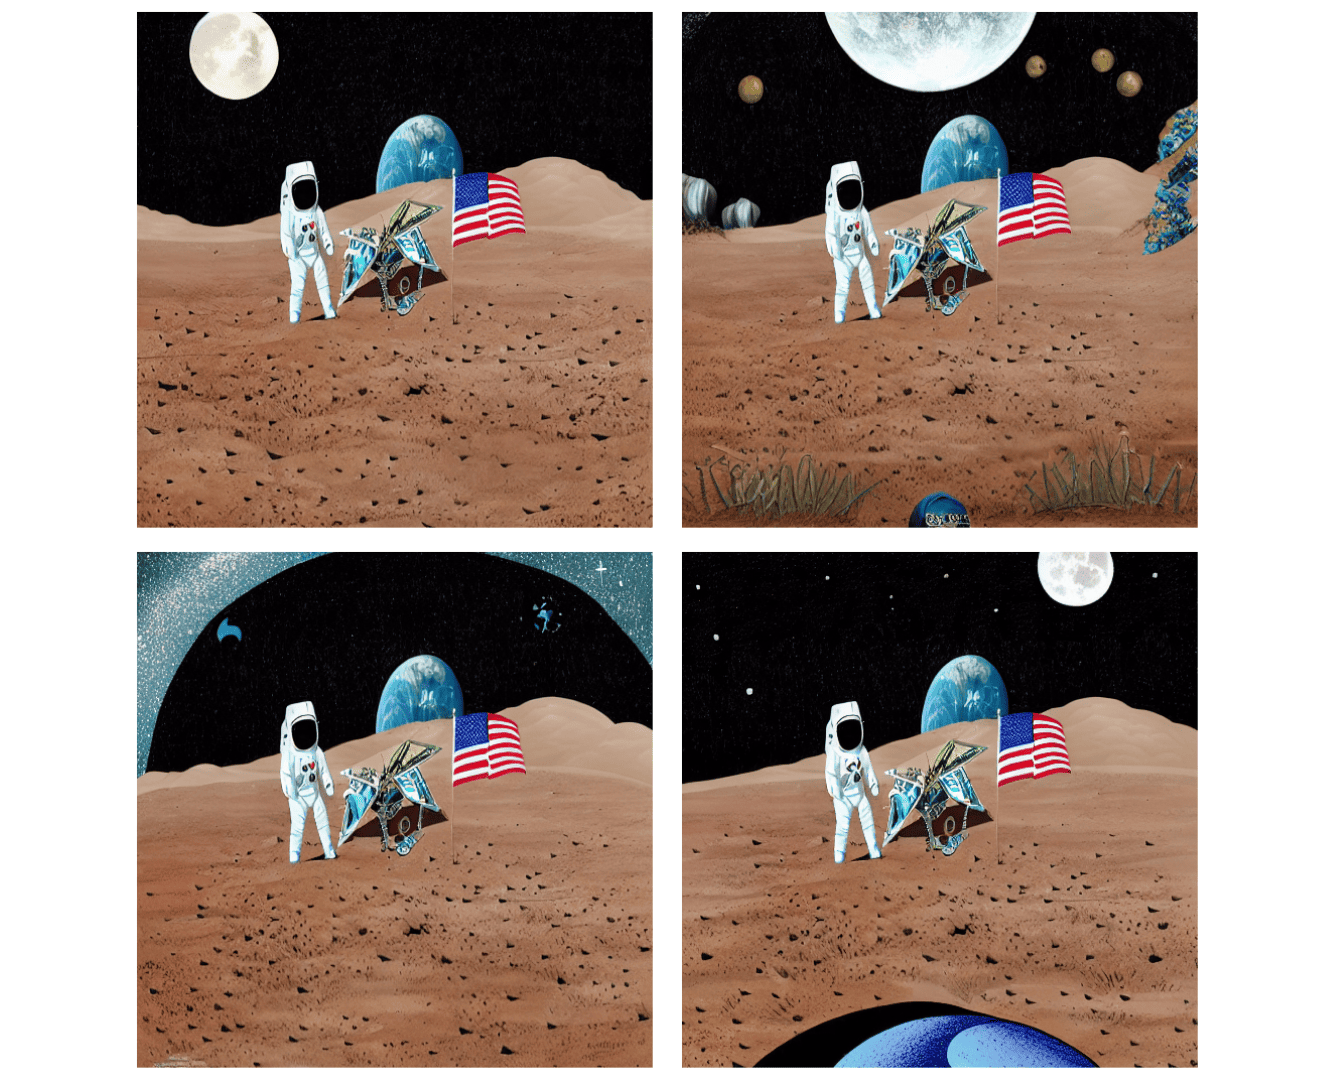

### **Prepare Canvas for Zoom Out**

In [ ]:
w, h = outpainted_image.size
new_w, new_h = w + 256, h + 256

# Background blur
bg = outpainted_image.resize((new_w, new_h), resample=Image.BICUBIC)
bg = bg.filter(ImageFilter.GaussianBlur(radius=50))
canvas_zoom = bg.copy()
canvas_zoom.paste(outpainted_image, (128, 128))

# Masker
mask_zoom = Image.new("L", (new_w, new_h), 255)
mask_zoom.paste(Image.new("L", (w, h), 0), (128, 128))

canvas_zoom.save("canvas_zoom.png")
mask_zoom.save("mask_zoom.png")

display_zoom = Image.new("RGB", (new_w * 2, new_h))
display_zoom.paste(canvas_zoom, (0, 0))
display_zoom.paste(mask_zoom.convert("RGB"), (new_w, 0))
display_zoom


### **Generate**

In [ ]:
outpainted_zoom_image = inpaint_engine(canvas_zoom, mask_zoom, "an extremely wide angle view of an astronaut on the moon, stars and galaxies, 2d digital art", strength=1.0)
outpainted_zoom_image.save("outpainted_zoom_image.png")
outpainted_zoom_image


## **Base + Refiner Image Generation**

In [ ]:
from diffusers import DiffusionPipeline
import torch

base = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0", torch_dtype=torch.float16, variant="fp16", use_safetensors=True
).to("cuda")

refiner = DiffusionPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-refiner-1.0",
    text_encoder_2=base.text_encoder_2,
    vae=base.vae,
    torch_dtype=torch.float16,
    use_safetensors=True,
    variant="fp16"
).to("cuda")

prompt = "a 2d digital art illustration of an astronaut on the moon, earth in the sky, white spacesuit"
seed = 222
generator = torch.Generator("cuda").manual_seed(seed)

latents = base(
    prompt=prompt,
    negative_prompt="blurry, bad anatomy, realistic, photo, 3d",
    generator=generator,
    num_inference_steps=40,
    denoising_end=0.8,
    output_type="latent"
).images

refiner_image = refiner(
    prompt=prompt,
    negative_prompt="blurry, bad anatomy, realistic, photo, 3d",
    generator=generator,
    num_inference_steps=40,
    denoising_start=0.8,
    image=latents
).images[0]

refiner_image.save("refiner_image.png")
refiner_image
